# Линейная регрессия: учебная тетрадка

В этой тетрадке мы повторяем ту же идею, что и в интерактивном приложении, но делаем расчёты в Python.

План:

1. Создадим маленькие игрушечные данные.
2. Вручную посчитаем коэффициенты прямой `ŷ = a·x + b`.
3. Проверим результат через `sklearn`.
4. Создадим нелинейные данные и сравним прямую с параболой.
5. Добавим выброс и посмотрим, как он тянет линию.
6. Загрузим реалистичный учебный CSV про квартиры.
7. Сравним модель по одному признаку и модель по нескольким признакам.

Главная цель: не просто получить числа, а понимать каждую строку расчёта.


## 1. Импорты

Ниже подключаются библиотеки:

- `numpy` помогает считать массивы, средние значения, суммы и квадраты;
- `pandas` читает CSV и показывает таблицы;
- `matplotlib` строит графики;
- `LinearRegression` обучает линейную модель из `sklearn`;
- `PolynomialFeatures` создаёт признак `x²` для параболы;
- `make_pipeline` соединяет преобразование признаков и модель;
- метрики из `sklearn.metrics` проверяют MSE, MAE и R².


In [1]:
import numpy as np                  # численные расчёты: массивы, средние, суммы
import pandas as pd                 # таблицы и чтение CSV-файлов
import matplotlib.pyplot as plt     # построение графиков

from sklearn.linear_model import LinearRegression                               # готовая линейная регрессия
from sklearn.preprocessing import PolynomialFeatures                            # создаёт признаки x^2, x^3 и так далее
from sklearn.pipeline import make_pipeline                                      # собирает несколько шагов в одну модель
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score   # метрики качества
from sklearn.model_selection import train_test_split                            # разделение данных на train и test

plt.rcParams['figure.figsize'] = (8, 5)     # общий размер графиков
plt.rcParams['axes.grid'] = True            # сетка помогает читать графики


## 2. Игрушечные линейные данные

Создадим маленький набор данных. Пусть `x` означает площадь квартиры в десятках квадратных метров, а `y` означает цену в миллионах рублей.

Данные почти лежат на прямой: чем больше площадь, тем выше цена.


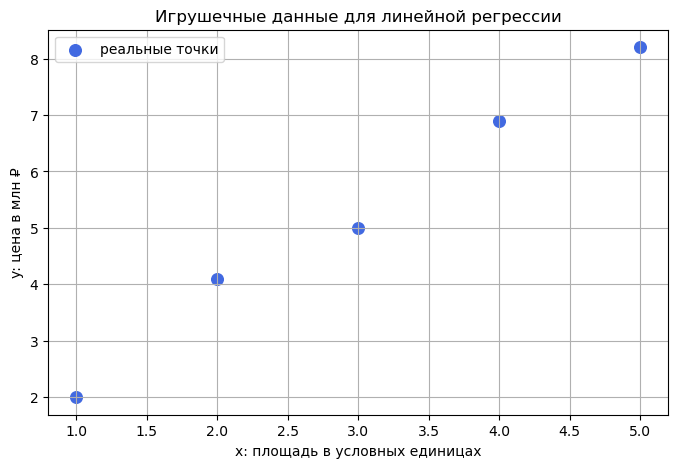

In [2]:
x = np.array([1, 2, 3, 4, 5], dtype=float)             # входной признак
y = np.array([2.0, 4.1, 5.0, 6.9, 8.2], dtype=float)   # настоящий ответ

plt.scatter(x, y, color='royalblue', s=70, label='реальные точки')
plt.xlabel('x: площадь в условных единицах')
plt.ylabel('y: цена в млн ₽')
plt.title('Игрушечные данные для линейной регрессии')
plt.legend()
plt.show()


## 3. Ручной расчёт коэффициентов

Формула модели:

`ŷ = a·x + b`

Мы хотим найти такие `a` и `b`, чтобы сумма квадратов ошибок была минимальной.

Сначала считаем средние значения:

- `x_mean` это среднее всех `x`;
- `y_mean` это среднее всех `y`.

Потом считаем:

- `Sxx = Σ(xᵢ - x_mean)²`: насколько сильно разбросаны значения `x`;
- `Sxy = Σ(xᵢ - x_mean)(yᵢ - y_mean)`: как `x` и `y` меняются вместе.

После этого:

`a = Sxy / Sxx`

`b = y_mean - a·x_mean`


In [3]:
x_mean = x.mean()                       # среднее значение x
y_mean = y.mean()                       # среднее значение y
x_centered = x - x_mean                 # отклонения x от среднего
y_centered = y - y_mean                 # отклонения y от среднего
Sxx = np.sum(x_centered ** 2)           # сумма квадратов отклонений x
Sxy = np.sum(x_centered * y_centered)   # сумма совместных отклонений x и y
a = Sxy / Sxx                           # наклон прямой
b = y_mean - a * x_mean                 # свободный член, чтобы линия проходила через центр данных

print(f'x_mean = {x_mean:.3f}')
print(f'y_mean = {y_mean:.3f}')
print(f'Sxx = {Sxx:.3f}')
print(f'Sxy = {Sxy:.3f}')
print(f'a = {a:.3f}')
print(f'b = {b:.3f}')
print(f'Итоговая линия: y_hat = {a:.3f} * x + {b:.3f}')


x_mean = 3.000
y_mean = 5.240
Sxx = 10.000
Sxy = 15.200
a = 1.520
b = 0.680
Итоговая линия: y_hat = 1.520 * x + 0.680


## 4. Предсказания, residuals и метрики вручную

Теперь посчитаем предсказания `ŷ`, остатки `residuals = y - ŷ` и метрики.

- `RSS` это сумма квадратов ошибок;
- `MSE` это средняя квадратичная ошибка;
- `RMSE` это корень из MSE, ошибка в исходных единицах;
- `MAE` это средняя абсолютная ошибка;
- `R²` сравнивает нашу модель с baseline-моделью “всегда предсказывать среднее y”.


In [4]:
y_pred = a * x + b                  # предсказания модели для каждого x
residuals = y - y_pred              # настоящие значения минус предсказания
squared_residuals = residuals ** 2  # квадраты ошибок
RSS = np.sum(squared_residuals)     # сумма квадратов ошибок
MSE = RSS / len(x)                  # средняя квадратичная ошибка
RMSE = np.sqrt(MSE)                 # корень из MSE
MAE = np.mean(np.abs(residuals))    # средняя абсолютная ошибка
TSS = np.sum((y - y_mean) ** 2)     # ошибка baseline-прогноза: всегда y_mean
R2 = 1 - RSS / TSS                  # насколько лучше модель по сравнению с baseline

manual_results = pd.DataFrame({
    'x': x,
    'y': y,
    'y_pred': y_pred,
    'residual': residuals,
    'residual^2': squared_residuals,
})

print(manual_results)
print('\nМетрики:')
print(f'RSS = {RSS:.3f}')
print(f'MSE = {MSE:.3f}')
print(f'RMSE = {RMSE:.3f}')
print(f'MAE = {MAE:.3f}')
print(f'R² = {R2:.3f}')


     x    y  y_pred  residual  residual^2
0  1.0  2.0    2.20     -0.20      0.0400
1  2.0  4.1    3.72      0.38      0.1444
2  3.0  5.0    5.24     -0.24      0.0576
3  4.0  6.9    6.76      0.14      0.0196
4  5.0  8.2    8.28     -0.08      0.0064

Метрики:
RSS = 0.268
MSE = 0.054
RMSE = 0.232
MAE = 0.208
R² = 0.989


Построим график. Вертикальные красные линии показывают residuals: расстояния от настоящих точек до линии модели.


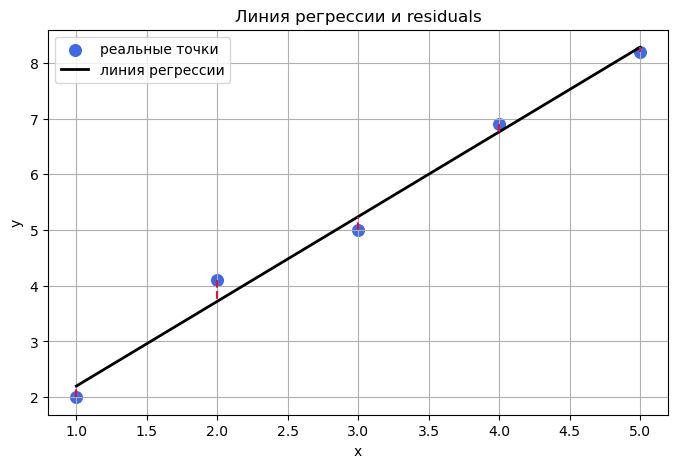

In [5]:
plt.scatter(x, y, color='royalblue', s=70, label='реальные точки')
plt.plot(x, y_pred, color='black', linewidth=2, label='линия регрессии')

for xi, yi, ypi in zip(x, y, y_pred):
    plt.plot([xi, xi], [yi, ypi], color='crimson', linestyle='--', linewidth=1.5)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Линия регрессии и residuals')
plt.legend()
plt.show()


## 5. Проверка через sklearn

Теперь обучим `LinearRegression` из `sklearn`. Если ручной расчёт был правильный, коэффициенты должны совпасть или быть очень близкими.


In [6]:
X = x.reshape(-1, 1)                    # sklearn ждёт матрицу признаков: строки = объекты, столбцы = признаки
linear_model = LinearRegression()       # создаём модель
linear_model.fit(X, y)                  # обучаем модель на x и y
sklearn_pred = linear_model.predict(X)  # получаем предсказания

print(f'Ручной a = {a:.6f}')
print(f'sklearn a = {linear_model.coef_[0]:.6f}')
print(f'Ручной b = {b:.6f}')
print(f'sklearn b = {linear_model.intercept_:.6f}')
print(f'MSE sklearn = {mean_squared_error(y, sklearn_pred):.6f}')
print(f'MAE sklearn = {mean_absolute_error(y, sklearn_pred):.6f}')
print(f'R² sklearn = {r2_score(y, sklearn_pred):.6f}')


Ручной a = 1.520000
sklearn a = 1.520000
Ручной b = 0.680000
sklearn b = 0.680000
MSE sklearn = 0.053600
MAE sklearn = 0.208000
R² sklearn = 0.988533


Коэффициенты совпадают, потому что `sklearn` решает ту же задачу: найти прямую с минимальной суммой квадратов ошибок.


## 6. Нелинейные данные: когда прямая слишком простая

Создадим данные, где зависимость похожа на параболу:

`y ≈ 0.05x² + 2x + шум`

Сначала попробуем обычную прямую. Потом добавим признак `x²` и построим квадратичную модель.


In [7]:
rng = np.random.default_rng(7)                                                        # генератор случайных чисел для повторяемости
x_curve = np.linspace(0, 10, 30)                                                      # 30 значений x от 0 до 10
y_curve = 0.05 * x_curve ** 2 + 2 * x_curve + rng.normal(0, 1.2, size=x_curve.shape)  # парабола + шум
X_curve = x_curve.reshape(-1, 1)                                                      # матрица признаков для sklearn

line_for_curve = LinearRegression()  # обычная прямая
line_for_curve.fit(X_curve, y_curve)
line_pred = line_for_curve.predict(X_curve)

poly_model = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())  # x -> x и x^2, затем регрессия
poly_model.fit(X_curve, y_curve)
poly_pred = poly_model.predict(X_curve)

print('Прямая:')
print(f'MSE = {mean_squared_error(y_curve, line_pred):.3f}')
print(f'R² = {r2_score(y_curve, line_pred):.3f}')

print('\nПарабола:')
print(f'MSE = {mean_squared_error(y_curve, poly_pred):.3f}')
print(f'R² = {r2_score(y_curve, poly_pred):.3f}')


Прямая:
MSE = 1.149
R² = 0.978

Парабола:
MSE = 0.907
R² = 0.983


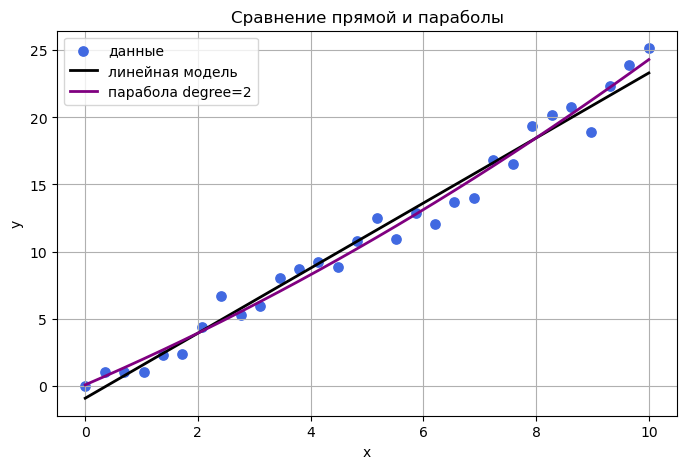

In [8]:
plt.scatter(x_curve, y_curve, color='royalblue', s=45, label='данные')
plt.plot(x_curve, line_pred, color='black', linewidth=2, label='линейная модель')
plt.plot(x_curve, poly_pred, color='purple', linewidth=2, label='парабола degree=2')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Сравнение прямой и параболы')
plt.legend()
plt.show()


Парабола обычно получает меньшую ошибку на таких данных, потому что форма данных действительно кривая. Но это не значит, что всегда нужно брать более сложную модель. Слишком гибкая модель может начать повторять шум, а не настоящую закономерность.


## 7. Выброс: почему одна странная точка опасна

Линейная регрессия минимизирует квадраты ошибок. Поэтому большой промах получает очень большой штраф. Из-за этого выброс может заметно потянуть линию.


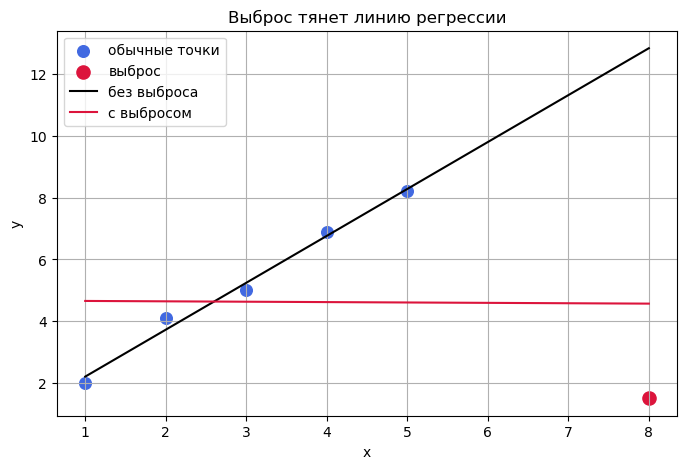

Наклон без выброса: 1.520
Наклон с выбросом: -0.012


In [9]:
x_outlier = np.append(x, 8)     # добавляем новую точку далеко справа
y_outlier = np.append(y, 1.5)   # её y необычно маленький для такого x
model_without_outlier = LinearRegression().fit(x.reshape(-1, 1), y)
model_with_outlier = LinearRegression().fit(x_outlier.reshape(-1, 1), y_outlier)
x_line = np.linspace(1, 8, 100).reshape(-1, 1)

plt.scatter(x, y, color='royalblue', s=70, label='обычные точки')
plt.scatter([8], [1.5], color='crimson', s=90, label='выброс')
plt.plot(x_line, model_without_outlier.predict(x_line), color='black', label='без выброса')
plt.plot(x_line, model_with_outlier.predict(x_line), color='crimson', label='с выбросом')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Выброс тянет линию регрессии')
plt.legend()
plt.show()

print(f'Наклон без выброса: {model_without_outlier.coef_[0]:.3f}')
print(f'Наклон с выбросом: {model_with_outlier.coef_[0]:.3f}')


## 8. Реалистичный учебный набор данных о квартирах

Файл `datasets/real_estate_realistic.csv` создан как реалистичный учебный набор данных, похожий на данные о квартирах. Это не реальные сделки, поэтому на защите важно честно говорить: данные сгенерированы для обучения.

Колонки:

- `area_m2`: площадь квартиры;
- `rooms`: количество комнат;
- `floor`: этаж;
- `distance_to_center_km`: расстояние до центра;
- `house_age`: возраст дома;
- `price_rub`: цена квартиры в рублях.


In [10]:
real_estate = pd.read_csv('../datasets/real_estate_realistic.csv')  # читаем CSV из папки datasets

real_estate.head()  # первые строки таблицы


,area_m2,rooms,floor,distance_to_center_km,house_age,price_rub
0,81.7,3,9,6.9,8,12116000
1,102.9,4,14,1.9,5,15481000
2,46.4,2,1,14.3,45,4191000
3,46.5,2,1,18.9,10,4265000
4,86.6,3,5,6.2,48,11389000


Посмотрим связь площади и цены. Обычно площадь важна, но цена зависит не только от неё.


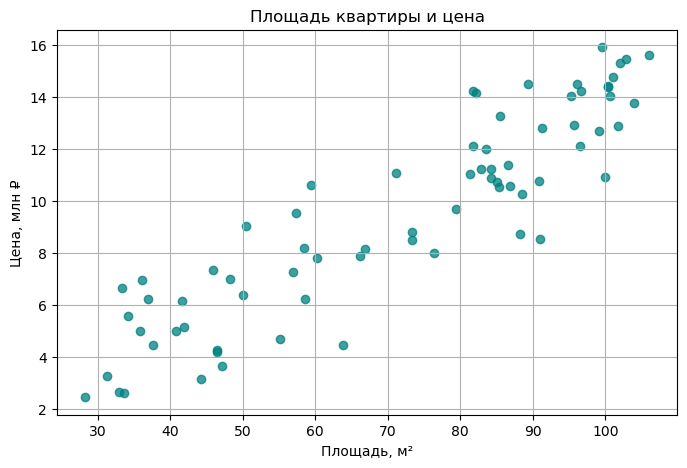

In [11]:
plt.scatter(real_estate['area_m2'], real_estate['price_rub'] / 1_000_000, color='teal', alpha=0.75)
plt.xlabel('Площадь, м²')
plt.ylabel('Цена, млн ₽')
plt.title('Площадь квартиры и цена')
plt.show()


### Разделение данных на обучающую и тестовую части

Разделим квартиры на две части. На обучающей выборке модель будет находить коэффициенты, а на тестовой — проверяться на объектах, которые не использовались при обучении.

In [12]:
train_data, test_data = train_test_split(
    real_estate,
    test_size=0.25,
    random_state=42,
)

print(f'Объектов в train: {len(train_data)}')
print(f'Объектов в test:  {len(test_data)}')

Объектов в train: 54
Объектов в test:  18


## 9. Простая модель: только площадь

Сначала обучим модель только по одному признаку `area_m2`. Это похоже на интерактивное приложение: один x и один y.


In [13]:
X_area_train = train_data[['area_m2']]  # площадь квартир для обучения
X_area_test = test_data[['area_m2']]    # площадь квартир для проверки
y_train = train_data['price_rub']       # настоящие цены обучающей выборки
y_test = test_data['price_rub']         # настоящие цены тестовой выборки
area_model = LinearRegression()
area_model.fit(X_area_train, y_train)   # обучаем только на train
area_pred = area_model.predict(X_area_test)  # прогнозируем цены для test

area_mse = mean_squared_error(y_test, area_pred)
area_rmse = np.sqrt(area_mse)
area_mae = mean_absolute_error(y_test, area_pred)
area_r2 = r2_score(y_test, area_pred)

print(f'a для площади = {area_model.coef_[0]:.2f} руб. за 1 м²')
print(f'b = {area_model.intercept_:.2f} руб.')
print(f'MSE на test = {area_mse:.2f}')
print(f'RMSE на test = {area_rmse:.2f} руб.')
print(f'MAE на test = {area_mae:.2f} руб.')
print(f'R² на test = {area_r2:.3f}')

a для площади = 145360.78 руб. за 1 м²
b = -1062689.07 руб.
MSE на test = 2442059874439.66
RMSE на test = 1562709.15 руб.
MAE на test = 1282489.08 руб.
R² на test = 0.860


## 10. Модель по нескольким признакам

Реальная цена квартиры зависит не только от площади. Добавим комнаты, этаж, расстояние до центра и возраст дома.

Формула становится такой:

`ŷ = w1·area + w2·rooms + w3·floor + w4·distance + w5·age + b`

Идея остаётся той же: подобрать коэффициенты так, чтобы сумма квадратов ошибок была минимальной.


In [14]:
feature_columns = [
    'area_m2',
    'rooms',
    'floor',
    'distance_to_center_km',
    'house_age',
]

X_multi_train = train_data[feature_columns]
X_multi_test = test_data[feature_columns]

multi_model = LinearRegression()
multi_model.fit(X_multi_train, y_train)         # обучаем только на train
multi_pred = multi_model.predict(X_multi_test)  # проверяем на test
multi_mse = mean_squared_error(y_test, multi_pred)
multi_rmse = np.sqrt(multi_mse)
multi_mae = mean_absolute_error(y_test, multi_pred)
multi_r2 = r2_score(y_test, multi_pred)

comparison = pd.DataFrame({
    'model': ['только площадь', 'несколько признаков'],
    'MSE': [area_mse, multi_mse],
    'RMSE': [area_rmse, multi_rmse],
    'MAE': [area_mae, multi_mae],
    'R2': [area_r2, multi_r2],
})

comparison

,model,MSE,RMSE,MAE,R2
0,только площадь,2.442060e+12,1.562709e+06,1.282489e+06,0.860158
1,несколько признаков,2.126724e+11,4.611642e+05,3.144829e+05,0.987822


In [15]:
coef_table = pd.DataFrame({
    'feature': feature_columns,
    'coefficient': multi_model.coef_,
})

coef_table


,feature,coefficient
0,area_m2,124527.183905
1,rooms,396796.793352
2,floor,39222.889060
3,distance_to_center_km,-187236.281608
4,house_age,-27920.794495


Если модель с несколькими признаками показывает меньшую ошибку и больший R², это логично: она знает больше о квартире. Но в реальных проектах важно проверять модель на новых данных, а не только на тех, где она обучалась.


## 11. Прогноз для новой квартиры

Используем обученную модель для прогноза цены квартиры, которой не было в исходном датасете.


In [16]:
new_apartment = pd.DataFrame({
    'area_m2': [75],
    'rooms': [3],
    'floor': [7],
    'distance_to_center_km': [6],
    'house_age': [12],
})

predicted_price = multi_model.predict(new_apartment)[0]

print(f'Прогнозируемая цена: {predicted_price:,.0f} руб.')
print(f'Прогнозируемая цена: {predicted_price / 1_000_000:.2f} млн ₽')

Прогнозируемая цена: 11,347,894 руб.
Прогнозируемая цена: 11.35 млн ₽


## 12. Вывод

Что важно запомнить:

- На простых линейных данных линейная регрессия понятна и хорошо работает.
- Коэффициенты `a` и `b` появляются из задачи минимизации RSS.
- Residual это вертикальная ошибка точки: `y - ŷ`.
- R² сравнивает модель не с идеалом, а с baseline-прогнозом “всегда среднее y”.
- Если зависимость кривая, парабола может описать данные лучше прямой.
- Выбросы могут сильно менять линию, потому что квадраты ошибок дают им большой вес.
- На реалистичных данных одного признака часто мало: цена квартиры зависит от нескольких факторов.
